In [2]:
import os
from pathlib import Path

import nibabel as nib
import numpy as np
import torch
from torch.utils.data import Dataset


class VolumeToNoisy2DDataset(Dataset):
    def __init__(self, vol_dir, img_dir, file_list=None, transform=None):
        """
        vol_dir : path to 3D volumes (33, 256, 256) NIfTI
        img_dir : path to 2D noisy images (256, 256) NIfTI
        file_list : optional list of stems (without .nii.gz) to use
        transform : optional callable taking (vol, img) -> (vol, img)
        """
        self.vol_dir = Path(vol_dir)
        self.img_dir = Path(img_dir)
        self.transform = transform

        all_vols = sorted([f for f in os.listdir(self.vol_dir)
                           if f.endswith(".nii") or f.endswith(".nii.gz")])

        if file_list is None:
            self.stems = []
            for fname in all_vols:
                stem = fname
                if stem.endswith(".nii.gz"):
                    stem = stem[:-7]
                elif stem.endswith(".nii"):
                    stem = stem[:-4]
                self.stems.append(stem)
        else:
            self.stems = file_list

    def __len__(self):
        return len(self.stems)

    def __getitem__(self, idx):
        stem = self.stems[idx]
        vol_path = self.vol_dir / f"{stem}.nii.gz"
        if not vol_path.exists():
            vol_path = self.vol_dir / f"{stem}.nii"  # fallback

        img_path = self.img_dir / f"{stem}_noisy2d.nii.gz"
        if not img_path.exists():
            img_path = self.img_dir / f"{stem}_noisy2d.nii"
        if not img_path.exists():
            img_path = self.img_dir / f"{stem}_ideal2d.nii.gz"
        if not img_path.exists():
            img_path = self.img_dir / f"{stem}_ideal2d.nii"

        # Load 3D volume (Z, H, W)
        vol = nib.load(str(vol_path)).get_fdata().astype(np.float32)
        # Ensure shape is (Z, H, W) and specifically (33, 256, 256)

        if vol.shape == (256, 256, 33):
            vol = np.transpose(vol, (2, 0, 1))  # (Z, H, W)
        if vol.shape != (33, 256, 256):
            raise ValueError(f"Unexpected volume shape {vol.shape} for {vol_path}")

        # Load 2D target (H, W)
        img = nib.load(str(img_path)).get_fdata().astype(np.float32)
        if img.shape != (256, 256):
            raise ValueError(f"Unexpected image shape {img.shape} for {img_path}")

        # Simple normalization (optional; adjust as you like)
        vol = vol / (np.max(vol) + 1e-6)
        #img = img / (np.max(img) + 1e-6)

        # Add channel dim for PyTorch: (C=1, Z, H, W) and (C=1, H, W)
        vol = vol[None, ...]   # (1, 33, 256, 256)
        img = img[None, ...]   # (1, 256, 256)

        vol_t = torch.from_numpy(vol)   # float32
        img_t = torch.from_numpy(img)

        if self.transform is not None:
            vol_t, img_t = self.transform(vol_t, img_t)

        return vol_t, img_t, stem

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class Simple3Dto2DNet(nn.Module):
    def __init__(self, in_channels=1, base_channels=16):
        super().__init__()
        # 3D encoder
        self.enc3d = nn.Sequential(
            nn.Conv3d(in_channels, base_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv3d(base_channels, base_channels * 2, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )
        # 2D head after pooling over Z
        self.head2d = nn.Sequential(
            nn.Conv2d(base_channels * 2, base_channels * 2, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_channels * 2, 1, kernel_size=3, padding=1)
        )

    def forward(self, x):
        """
        x: (B, 1, Z, H, W)
        """
        feat3d = self.enc3d(x)          # (B, C, Z, H', W')
        # global average over Z
        feat2d = feat3d.mean(dim=2)     # (B, C, H', W')

        # if we downsampled, upsample back to 256x256
        out2d = self.head2d(feat2d)     # (B, 1, H', W')
        out2d = F.interpolate(out2d, size=(256, 256),
                              mode="bilinear", align_corners=False)
        return out2d

In [12]:
from torch.utils.data import DataLoader
import torch.optim as optim

# config
VOL_DIR = "MiniVess/post/"
IMG_DIR = "MiniVess/out_ideal/"
BATCH_SIZE = 2
NUM_EPOCHS = 100
LR = 1e-3
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# dataset / dataloaders
full_dataset = VolumeToNoisy2DDataset(VOL_DIR, IMG_DIR)
n_total = len(full_dataset)
n_train = int(0.8 * n_total)
n_val = n_total - n_train
train_ds, val_ds = torch.utils.data.random_split(full_dataset, [n_train, n_val])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=4)

# model / optimizer / loss
model = Simple3Dto2DNet(in_channels=1, base_channels=16).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LR)
l1 = nn.L1Loss()
mse = nn.MSELoss()

for epoch in range(NUM_EPOCHS):
    model.train()
    train_loss = 0.0
    for vols, imgs, _ in train_loader:
        vols = vols.to(DEVICE)   # (B, 1, 33, 256, 256)
        imgs = imgs.to(DEVICE)   # (B, 1, 256, 256)

        optimizer.zero_grad()
        preds = model(vols)
        loss_l1 = l1(preds, imgs)
        loss_mse = mse(preds, imgs)
        loss = 0.5 * loss_l1 + 0.5 * loss_mse   # combined loss
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * vols.size(0)

    train_loss /= n_train

    # validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for vols, imgs, _ in val_loader:
            vols = vols.to(DEVICE)
            imgs = imgs.to(DEVICE)
            preds = model(vols)
            loss_l1 = l1(preds, imgs)
            loss_mse = mse(preds, imgs)
            loss = 0.5 * loss_l1 + 0.5 * loss_mse   # combined loss
            val_loss += loss.item() * vols.size(0)

    val_loss /= n_val
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}  TrainLoss={train_loss:.4e}  ValLoss={val_loss:.4e}")

Epoch 1/100  TrainLoss=4.0428e+09  ValLoss=3.6455e+09
Epoch 2/100  TrainLoss=2.0147e+09  ValLoss=2.6611e+08
Epoch 3/100  TrainLoss=2.6710e+08  ValLoss=1.8243e+08
Epoch 4/100  TrainLoss=2.3908e+08  ValLoss=1.6570e+08
Epoch 5/100  TrainLoss=2.0829e+08  ValLoss=1.5251e+08
Epoch 6/100  TrainLoss=1.8794e+08  ValLoss=1.3624e+08
Epoch 7/100  TrainLoss=1.6480e+08  ValLoss=1.2437e+08
Epoch 8/100  TrainLoss=1.4814e+08  ValLoss=1.1316e+08
Epoch 9/100  TrainLoss=1.2856e+08  ValLoss=1.1205e+08
Epoch 10/100  TrainLoss=1.1655e+08  ValLoss=9.6843e+07
Epoch 11/100  TrainLoss=1.0393e+08  ValLoss=9.2022e+07
Epoch 12/100  TrainLoss=9.8978e+07  ValLoss=8.8795e+07
Epoch 13/100  TrainLoss=8.9006e+07  ValLoss=9.4463e+07
Epoch 14/100  TrainLoss=9.1303e+07  ValLoss=8.6398e+07
Epoch 15/100  TrainLoss=8.6325e+07  ValLoss=8.4745e+07
Epoch 16/100  TrainLoss=8.4319e+07  ValLoss=8.6222e+07
Epoch 17/100  TrainLoss=8.3284e+07  ValLoss=8.4412e+07
Epoch 18/100  TrainLoss=8.3420e+07  ValLoss=8.4453e+07
Epoch 19/100  Train

In [10]:
def joint_normalize_for_display(pred, target, clip_percent=1.0):
    x = np.stack([pred, target], axis=0).astype(np.float32)
    lo = np.percentile(x, clip_percent)
    hi = np.percentile(x, 100 - clip_percent)
    x = np.clip(x, lo, hi)

    x -= x.min()
    if x.max() > 0:
        x /= x.max()
    return x[0], x[1]

In [12]:
def normalize_for_display(img, clip_percent=1.0):
    """
    img: 2D numpy array
    clip_percent: how aggressively to clip extremes (in % of histogram)
    """
    x = img.astype(np.float32).copy()
    # optional: remove extreme outliers for better contrast
    lo = np.percentile(x, clip_percent)
    hi = np.percentile(x, 100 - clip_percent)
    x = np.clip(x, lo, hi)

    x -= x.min()
    if x.max() > 0:
        x /= x.max()
    return x

In [26]:
import torch
import matplotlib.pyplot as plt
import numpy as np

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model.eval()

# get one batch from val_loader
#vols, imgs, stems = next(iter(val_loader))

idx = int(torch.randint(0, len(val_ds), (1,)))
vol, img, stem = val_ds[idx]
vols = vol.unsqueeze(0).to(DEVICE)   # (1, 1, 33, 256, 256)
imgs = img.unsqueeze(0).to(DEVICE)   # (1, 1, 256, 256)

with torch.no_grad():
    preds = model(vols)

# choose index in batch to visualize
i = 0
pred = preds[i, 0].cpu().numpy()
target = img[i].cpu().numpy()

pred_v, targ_v = joint_normalize_for_display(pred, target, clip_percent=1.0)
diff = normalize_for_display(np.abs(pred - target), clip_percent=1.0)

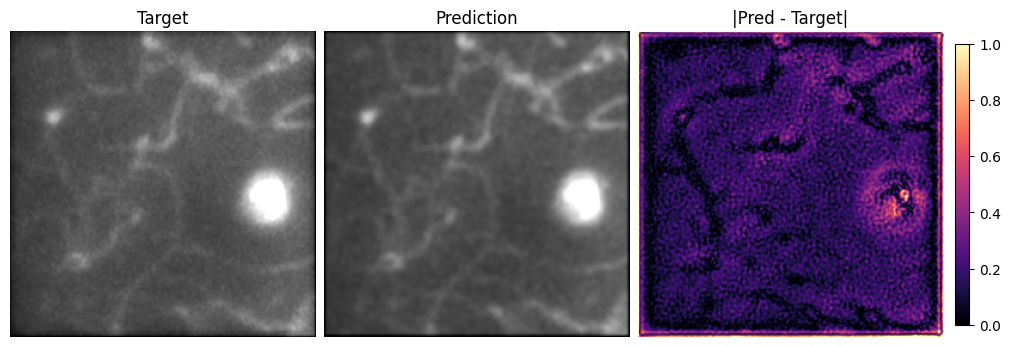

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(10, 4), constrained_layout=True)

axes[0].imshow(targ_v, cmap="gray"); axes[0].set_title("Target"); axes[0].axis("off")
axes[1].imshow(pred_v, cmap="gray"); axes[1].set_title("Prediction"); axes[1].axis("off")

im = axes[2].imshow(diff, cmap="magma")
axes[2].set_title("|Pred - Target|"); axes[2].axis("off")
fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
plt.show()

In [23]:
save_path = "simple3dto2d_epoch100_ideal.pth"
torch.save(model.state_dict(), save_path)

In [28]:
import numpy as np

p = pred.flatten()
t = target.flatten()

# remove NaNs/Infs if any
mask = np.isfinite(p) & np.isfinite(t)
p = p[mask]
t = t[mask]

corr = np.corrcoef(p, t)[0, 1]
print("Pearson correlation:", corr)
print("pred mean/std:", p.mean(), p.std())
print("targ mean/std:", t.mean(), t.std())

Pearson correlation: 0.9846047866861525
pred mean/std: 69103.6 14244.022
targ mean/std: 70805.6 13873.246


In [ ]:
# --- cell: model definition ---

class Backbone3Dto2D(nn.Module):
    """
    Simple 3D encoder that outputs a 2D map (unwarped).
    Input:  (B,1,33,256,256)
    Output: (B,1,256,256)
    """
    def __init__(self, in_channels=1, base_channels=16):
        super().__init__()
        self.enc3d = nn.Sequential(
            nn.Conv3d(in_channels, base_channels, 3, padding=1, padding_mode= 'reflect'),
            nn.ReLU(inplace=True),
            nn.Conv3d(base_channels, base_channels * 2, 3, padding=1, padding_mode= 'reflect'),
            nn.ReLU(inplace=True),
        )
        self.head2d = nn.Sequential(
            nn.Conv2d(base_channels * 2, base_channels * 2, 3, padding=1, padding_mode= 'reflect'),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_channels * 2, 1, 3, padding=1, padding_mode= 'reflect')
        )

    def forward(self, x):
        # x: (B,1,Z,H,W)
        feat3d = self.enc3d(x)         # (B,C,Z,H,W)
        feat2d = feat3d.mean(dim=2)    # average over Z -> (B,C,H,W)
        out2d = self.head2d(feat2d)    # (B,1,H,W)  (H=W=256)
        return out2d


class WarpMLP(nn.Module):
    def __init__(self, n_freqs=4, hidden_dim=16):
        super().__init__()
        in_dim = 2 * 2 * n_freqs  # sin/cos for x,y per freq

        self.mlp = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 2),
            nn.Tanh(),  # keep displacements in [-1,1]
        )
        self.n_freqs = n_freqs

    def encode(self, coords):
        # coords: (N,2) in [-1,1]
        x, y = coords[:, 0:1], coords[:, 1:2]
        out = []
        for k in range(self.n_freqs):
            freq = 2.0 ** k * np.pi
            out += [torch.sin(freq * x), torch.cos(freq * x),
                    torch.sin(freq * y), torch.cos(freq * y)]
        return torch.cat(out, dim=-1)  # (N, in_dim)

    def forward(self, H, W, device=None):
        if device is None:
            device = next(self.parameters()).device

        ys, xs = torch.meshgrid(
            torch.linspace(-1.0, 1.0, H, device=device),
            torch.linspace(-1.0, 1.0, W, device=device),
            indexing="ij",
        )
        base = torch.stack([xs, ys], dim=-1).view(-1, 2)  # (HW,2)
        enc  = self.encode(base)                          # (HW,in_dim)
        disp = self.mlp(enc).view(H, W, 2)                # (H,W,2)
        warped = (base.view(H, W, 2) + disp).clamp(-1, 1)
        return warped.unsqueeze(0)  # (1,H,W,2)


class ForwardWarpedModel(nn.Module):
    """
    Combines backbone (unwarped forward) + global warp MLP.
    """
    def __init__(self, in_channels=1, base_channels=16, warp_hidden=64):
        super().__init__()
        self.backbone = Backbone3Dto2D(in_channels, base_channels)
        self.warp_mlp = WarpMLP(hidden_dim=warp_hidden)

    def forward(self, x):
        """
        x: (B,1,Z,H,W)
        returns:
          unwarped: (B,1,H,W)
          warped:   (B,1,H,W)
        """
        B, C, Z, H, W = x.shape
        unwarped = self.backbone(x)               # (B,1,H,W)

        grid = self.warp_mlp(H, W, device=x.device)     # (1,H,W,2)
        grid = grid.expand(B, -1, -1, -1)               # same global warp for all batch

        warped = F.grid_sample(
            unwarped, grid,
            mode="bilinear", padding_mode="border", align_corners=False
        )  # (B,1,H,W)

        return unwarped, warped

In [7]:
# --- cell: create datasets and model ---
from torch.utils.data import DataLoader
VOL_DIR = "MiniVess/post/"
IMG_DIR = "MiniVess/out_2/"
BATCH_SIZE = 2
NUM_EPOCHS = 100
LR = 1e-3
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# dataset / dataloaders
full_dataset = VolumeToNoisy2DDataset(VOL_DIR, IMG_DIR)
n_total = len(full_dataset)
n_train = int(0.8 * n_total)
n_val = n_total - n_train
train_ds, val_ds = torch.utils.data.random_split(full_dataset, [n_train, n_val])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=2)

model = ForwardWarpedModel(in_channels=1, base_channels=16, warp_hidden=16).to(DEVICE)

l1 = nn.L1Loss()
mse = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

def combined_loss(pred, target, alpha=0.5, lambda_spec=0.0):
    """
    Pixel loss (L1+MSE); spectral part optional (lambda_spec can be 0).
    """
    loss_pix = alpha * l1(pred, target) + (1 - alpha) * mse(pred, target)
    if lambda_spec > 0:
        # simple magnitude spectral loss
        P = torch.fft.rfft2(pred, norm="ortho")
        T = torch.fft.rfft2(target, norm="ortho")
        loss_spec = l1(torch.abs(P), torch.abs(T))
        return loss_pix + lambda_spec * loss_spec
    else:
        return loss_pix

In [54]:
# --- cell: training loop ---
NUM_EPOCHS = 50
for epoch in range(NUM_EPOCHS):
    model.train()
    train_loss = 0.0

    for vols, imgs, _ in train_loader:
        vols = vols.to(DEVICE)   # (B,1,33,256,256)
        imgs = imgs.to(DEVICE)   # (B,1,256,256)  (warped+noisy targets)

        optimizer.zero_grad()
        unwarped, warped = model(vols)
        loss = combined_loss(warped, imgs, alpha=0.5, lambda_spec=0.0)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * vols.size(0)

    train_loss /= n_train

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for vols, imgs, _ in val_loader:
            vols = vols.to(DEVICE)
            imgs = imgs.to(DEVICE)
            _, warped = model(vols)
            loss = combined_loss(warped, imgs, alpha=0.5, lambda_spec=0.0)
            val_loss += loss.item() * vols.size(0)

    val_loss /= n_val
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}  Train={train_loss:.4e}  Val={val_loss:.4e}")

Epoch 1/50  Train=1.3054e+08  Val=1.5852e+08
Epoch 2/50  Train=1.3080e+08  Val=1.5021e+08
Epoch 3/50  Train=1.2293e+08  Val=1.5092e+08
Epoch 4/50  Train=1.4723e+08  Val=1.7290e+08
Epoch 5/50  Train=1.2750e+08  Val=2.1383e+08
Epoch 6/50  Train=1.2396e+08  Val=2.1652e+08
Epoch 7/50  Train=1.3064e+08  Val=1.6780e+08
Epoch 8/50  Train=1.2488e+08  Val=1.8378e+08
Epoch 9/50  Train=1.4137e+08  Val=1.6252e+08
Epoch 10/50  Train=1.2983e+08  Val=1.5986e+08
Epoch 11/50  Train=1.2778e+08  Val=1.4663e+08
Epoch 12/50  Train=1.2646e+08  Val=1.9507e+08
Epoch 13/50  Train=1.3350e+08  Val=2.1341e+08
Epoch 14/50  Train=1.2844e+08  Val=1.6997e+08
Epoch 15/50  Train=1.2724e+08  Val=1.6968e+08
Epoch 16/50  Train=1.2309e+08  Val=1.5077e+08
Epoch 17/50  Train=1.3113e+08  Val=1.7996e+08
Epoch 18/50  Train=1.3632e+08  Val=1.7045e+08
Epoch 19/50  Train=1.2566e+08  Val=1.6595e+08
Epoch 20/50  Train=1.2968e+08  Val=1.4919e+08
Epoch 21/50  Train=1.2554e+08  Val=2.2459e+08
Epoch 22/50  Train=1.2527e+08  Val=2.2803e+

In [55]:
model.eval()

# get one batch from val_loader
#vols, imgs, stems = next(iter(val_loader))

idx = int(torch.randint(0, len(val_ds), (1,)))
vol, img, stem = val_ds[idx]
vols = vol.unsqueeze(0).to(DEVICE)   # (1, 1, 33, 256, 256)
imgs = img.unsqueeze(0).to(DEVICE)   # (1, 1, 256, 256)

with torch.no_grad():
    unwarped, warped = model(vols)

# choose index in batch to visualize
pred = warped[0, 0].cpu().numpy()
target = imgs[0, 0].cpu().numpy()

pred_v, targ_v = joint_normalize_for_display(pred, target, clip_percent=1.0)
diff = normalize_for_display(np.abs(pred - target), clip_percent=1.0)

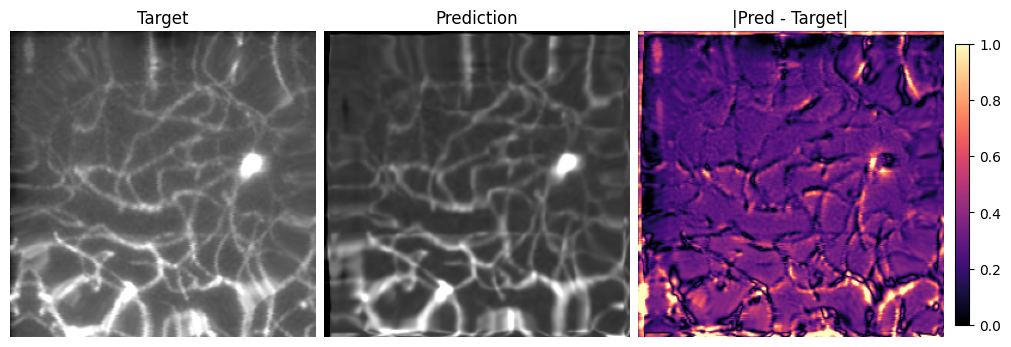

In [56]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(10, 4), constrained_layout=True)

axes[0].imshow(targ_v, cmap="gray"); axes[0].set_title("Target"); axes[0].axis("off")
axes[1].imshow(pred_v, cmap="gray"); axes[1].set_title("Prediction"); axes[1].axis("off")

im = axes[2].imshow(diff, cmap="magma")
axes[2].set_title("|Pred - Target|"); axes[2].axis("off")
fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
plt.show()

In [16]:
def joint_normalize_3(a, b, c, clip_percent=1.0):
    """
    Jointly normalize three images to [0,1] with shared clipping range.
    """
    x = np.stack([a, b, c], axis=0).astype(np.float32)
    lo = np.percentile(x, clip_percent)
    hi = np.percentile(x, 100 - clip_percent)
    x = np.clip(x, lo, hi)

    x -= x.min()
    if x.max() > 0:
        x /= x.max()
    return x[0], x[1], x[2]

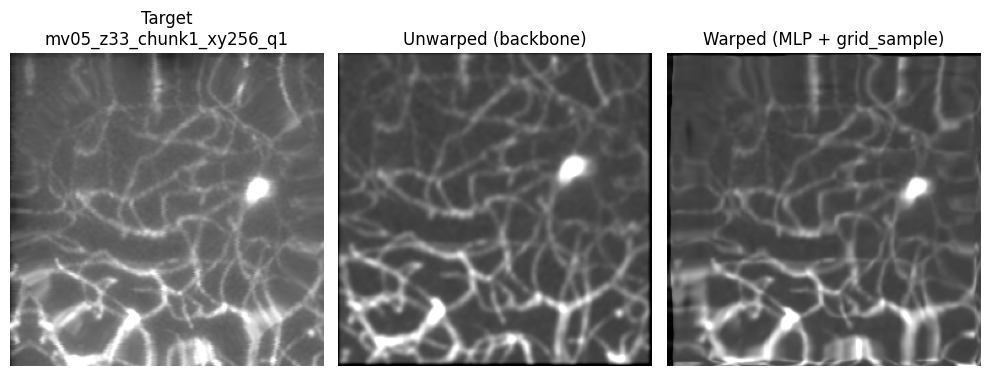

In [57]:
u = unwarped[0, 0].cpu().numpy()
w_v, u_v, t_v = joint_normalize_3(pred, u, target, clip_percent=1.0)
plt.figure(figsize=(10, 4))
plt.subplot(1, 3, 1)
plt.imshow(t_v, cmap="gray"); plt.title(f"Target\n{stem}"); plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(u_v, cmap="gray"); plt.title("Unwarped (backbone)"); plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(w_v, cmap="gray"); plt.title("Warped (MLP + grid_sample)"); plt.axis("off")

plt.tight_layout()
plt.show()

In [58]:
save_path = "ForwardWarpedModel_epoch250_warp.pth"
torch.save(model.state_dict(), save_path)